### Previsão de Geração Solar Fotovoltaica - DADOS METEREOLÓGICOS REAIS
TCC de Antonio Madruga de Carvalho Netto (UFPB, 2026).

Simulação utilizando dados reais da usina UFPB Mangabeira (Mar/2023 - Set/2024).

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
import warnings
import os
warnings.filterwarnings('ignore')

# Configurações de visualização
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

## 1. Carregamento e Preparação dos Dados
Esta etapa carrega o CSV, limpa valores inconsistentes e estima a geração baseada nas variáveis climáticas.

In [ ]:
def carregar_e_preparar_dados():
    print("\n📂 Carregando dados reais da usina UFPB Mangabeira...")

    # Carregar dados
    df = pd.read_csv('dados_climaticos.csv')

    print(f"✓ {len(df)} registros carregados")
    print(f"   Período: {df['datetime'].iloc[0]} até {df['datetime'].iloc[-1]}")

    df['datetime'] = pd.to_datetime(df['datetime'])

    # Renomear colunas para facilitar leitura posterior
    df = df.rename(columns={
        'PT100;temperature;Avg': 'temperatura',
        'T/H;humidity;Avg': 'umidade',
        'Delta T;solar_irradiance;Avg': 'irradiancia',
        'ANE;wind_speed;Avg': 'velocidade_vento',
        'PIRAN 01;solar_irradiance;Avg': 'irradiancia_alt',
        'Delta T;solar_irradiance_diffuse;Avg': 'irradiancia_difusa',
        'PLUV;precipitation;Sum': 'precipitacao',
        'wind_direction':'direçao_vento'
    })

    print("\n🧹 Limpando dados...")
    for col in ['irradiancia_difusa']:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    df = df[df['temperatura'] > 0].copy()
    df = df[df['irradiancia'] >= 0].copy()
    df = df.ffill().bfill()

    print(f"✓ {len(df)} registros após limpeza")
    print("\n⚡ Calculando geração fotovoltaica estimada...")

    # Equação considerada para a geração FV no sistema

    k = 0.12  # Fator de conversão
    beta = 0.004  # Coeficiente de temperatura

    df['geracao_fv'] = k * df['irradiancia'] * (1 - beta * (df['temperatura'] - 25))
    df['geracao_fv'] = df['geracao_fv'].clip(lower=0)

    df['hora'] = df['datetime'].dt.hour
    df['mes'] = df['datetime'].dt.month
    df['dia_ano'] = df['datetime'].dt.dayofyear

    df_diurno = df[(df['hora'] >= 5) & (df['hora'] <= 18) & (df['geracao_fv'] > 0)].copy()   # O período entre 5:00h e 18:00 (horário diurno) foi considerado como intervalo de tempo em que ocorre geração pelo sistema FV

    df_diario = df_diurno.groupby(df_diurno['datetime'].dt.date).agg({
        'irradiancia': 'mean',
        'temperatura': 'mean',
        'umidade': 'mean',
        'velocidade_vento': 'mean',
        'geracao_fv': 'sum',
        'precipitacao': 'sum'
    }).reset_index()

    df_diario.rename(columns={'datetime': 'data'}, inplace=True);
    df_diario['data'] = pd.to_datetime(df_diario['data'])

    print(f"\n📊 Dados agregados por dia: {len(df_diario)} dias")

    return df_diario, df_diurno

In [ ]:
df_diario, df_diurno = carregar_e_preparar_dados()
print('df_diario:');
display(df_diario.head())


📂 Carregando dados reais da usina UFPB Mangabeira...
✓ 82944 registros carregados
   Período: 2023-03-01 00:00:00 até 2024-09-27 23:50:00

🧹 Limpando dados...
✓ 81253 registros após limpeza

⚡ Calculando geração fotovoltaica estimada...

📊 Dados agregados por dia: 572 dias
df_diario:


,data,irradiancia,temperatura,umidade,velocidade_vento,geracao_fv,precipitacao
0,2023-03-01,527.468345,39.439989,69.538082,1.709001,4883.190377,0.0
1,2023-03-02,244.423312,31.505345,78.553706,1.639562,2361.087732,1.2
2,2023-03-03,531.306625,40.109431,71.181165,1.506700,4910.733027,0.0
3,2023-03-04,521.430899,39.852769,69.947135,1.740404,4823.835557,0.0
4,2023-03-05,500.297989,39.166657,70.813963,1.226198,4633.892263,0.0


In [ ]:
print('df_diurno:');
display(df_diurno.head())

df_diurno:


,datetime,velocidade_vento,WV;wind_direction;Avg,umidade,temperatura,T/H;temperature;Avg,irradiancia,irradiancia_alt,irradiancia_difusa,Delta T;solar_irradiance_direct_sw;Avg,Delta T;sun_status;Avg,Delta T;sun_status_sw;Avg,PLUV;precipitation;Count,precipitacao,geracao_fv,hora,mes,dia_ano
30,2023-03-01 05:00:00,0.6045,92.6681,80.8910,24.986882,26.74569,0.8418,0.000000,0.5448,---,0.0,---,600,0.0,0.101021,5,3,60
31,2023-03-01 05:10:00,0.6082,101.2962,80.9040,24.914937,26.71079,2.3281,0.024631,1.9069,---,0.0,---,600,0.0,0.279467,5,3,60
32,2023-03-01 05:20:00,0.4039,103.6253,80.7226,24.776293,26.64904,6.4160,3.175797,6.0661,---,0.0,---,600,0.0,0.770609,5,3,60
33,2023-03-01 05:30:00,1.0509,99.3344,79.4845,24.958351,26.65669,15.8783,13.613522,15.3096,23.8242,0.0,0.0054,600,0.0,1.905713,5,3,60
34,2023-03-01 05:40:00,0.4473,98.6344,78.9845,25.161405,26.76740,35.3069,32.782759,33.5027,24.0994,0.0,0.0000,600,0.0,4.234093,5,3,60


## 2. Preparação das técnicas de Machine Learning e Métricas de Avaliação
Separação de dados de treino e teste, padronização (Scaler) e definição das funções de métricas (MSE, RMSE, MAE, MAPE, R²).

In [ ]:
def preparar_dados_ml(dados):
    X = dados[['irradiancia', 'temperatura', 'umidade', 'velocidade_vento']].values
    y = dados['geracao_fv'].values

    X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
        X, y, dados.index, test_size=0.2, random_state=42
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    return X_train_scaled, X_test_scaled, y_train, y_test, scaler, idx_test

def calcular_metricas(y_real, y_pred, nome_modelo):
    mse = mean_squared_error(y_real, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_real, y_pred)
    mask = y_real != 0
    mape = mean_absolute_percentage_error(y_real[mask], y_pred[mask]) * 100
    r2 = r2_score(y_real, y_pred)

    print(f"\n{'='*60}")
    print(f"MÉTRICAS DE DESEMPENHO - {nome_modelo}")
    print(f"{'='*60}")
    print(f"MSE:   {mse:.4f}")
    print(f"RMSE:  {rmse:.4f}")
    print(f"MAE:   {mae:.4f}")
    print(f"MAPE:  {mape:.2f}%")
    print(f"R²:    {r2:.4f}")
    print(f"{'='*60}\n")

    return {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'MAPE': mape, 'R2': r2}

## 3. Treinamento dos Modelos de Machine Learning
Funções para treinar Random Forest, Gradient Boosting (XGBoost base), SVM e Redes Neurais.

In [ ]:
def treinar_random_forest(X_train, y_train, X_test, y_test):
    print("\n🌲 Treinando Random Forest...")
    rf = RandomForestRegressor(random_state=42, n_jobs=-1)
    param_grid = {'n_estimators': [100, 200], 'max_depth': [15, 25], 'min_samples_split': [2, 5]}

    grid_search = GridSearchCV(rf, param_grid, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
    grid_search.fit(X_train, y_train)

    best_rf = grid_search.best_estimator_
    y_pred = best_rf.predict(X_test)
    metricas = calcular_metricas(y_test, y_pred, "Random Forest")
    return best_rf, y_pred, metricas

def treinar_gradient_boosting(X_train, y_train, X_test, y_test):
    print("\n🚀 Treinando Gradient Boosting...")
    gb = GradientBoostingRegressor(n_estimators=200, max_depth=7, learning_rate=0.1, random_state=42)
    gb.fit(X_train, y_train)
    y_pred = gb.predict(X_test)
    metricas = calcular_metricas(y_test, y_pred, "Gradient Boosting")
    return gb, y_pred, metricas

def treinar_svm(X_train, y_train, X_test, y_test):
    print("\n🎯 Treinando SVM...")
    svm = SVR(kernel='rbf', C=100, gamma='scale', epsilon=0.1)
    svm.fit(X_train, y_train)
    y_pred = svm.predict(X_test)
    metricas = calcular_metricas(y_test, y_pred, "Support Vector Machine")
    return svm, y_pred, metricas

def treinar_rede_neural(X_train, y_train, X_test, y_test):
    print("\n🧠 Treinando Rede Neural Artificial...")
    mlp = MLPRegressor(hidden_layer_sizes=(128, 64, 32), activation='relu', solver='adam',
                       max_iter=1000, random_state=42, early_stopping=True)
    mlp.fit(X_train, y_train)
    y_pred = mlp.predict(X_test)
    metricas = calcular_metricas(y_test, y_pred, "Rede Neural Artificial (MLP)")
    return mlp, y_pred, metricas

## 4. Visualizações Gráficas
Funções de plotagem exploratória e de comparação dos modelos.

In [ ]:
def plotar_dados_reais(dados_diarios, dados_horarios):
    print("\n📊 Gerando gráficos de análise...")
    fig = plt.figure(figsize=(18, 18)) # Tamanho aumentado para receber mais plots
    gs = fig.add_gridspec(3, 3, hspace=0.4, wspace=0.3)
    fig.suptitle('Análise dos Dados Reais - Usina UFPB Mangabeira', fontsize=16, fontweight='bold', y=0.98)

    # 1. Série temporal (diária)
    ax1 = fig.add_subplot(gs[0, :]) # Agrupa todas as colunas na primeira linha
    ax1.plot(dados_diarios['data'], dados_diarios['geracao_fv'], color='#2ecc71', linewidth=1.5)
    ax1.set_title('Geração Fotovoltaica Diária ao Longo do Período')
    ax1.set_xlabel('Data')
    ax1.set_ylabel('Geração (kWh)')
    ax1.grid(True, alpha=0.3)

    # 2. Irradiância vs Geração
    ax2 = fig.add_subplot(gs[1, 0])
    ax2.scatter(dados_diarios['irradiancia'], dados_diarios['geracao_fv'], alpha=0.6, color='#3498db')
    ax2.set_title('Irradiância Média Diária vs Geração')
    ax2.set_xlabel('Irradiância Média (W/m²)')
    ax2.set_ylabel('Geração Diária (kWh)')
    ax2.grid(True, alpha=0.3)

    # 3. Temperatura vs Geração
    ax3 = fig.add_subplot(gs[1, 1])
    ax3.scatter(dados_diarios['temperatura'], dados_diarios['geracao_fv'], color='#e74c3c', alpha=0.6)
    ax3.set_title('Temperatura Média Diária vs Geração')
    ax3.set_xlabel('Temperatura Média (°C)')
    ax3.set_ylabel('Geração Diária (kWh)')
    ax3.grid(True, alpha=0.3)

    # 4. Distribuição da Irradiância
    ax4 = fig.add_subplot(gs[1, 2])
    ax4.hist(dados_diarios['irradiancia'], bins=30, color='#f39c12', edgecolor='black', alpha=0.7)
    ax4.set_title('Distribuição da Irradiância Diária')
    ax4.set_xlabel('Irradiância Média (W/m²)')
    ax4.set_ylabel('Frequência')
    ax4.grid(True, alpha=0.3)

    # 5. Padrão horário de Geração (from df_diurno)
    ax5 = fig.add_subplot(gs[2, :]) # Spans all columns in the third row
    geracao_hora = dados_horarios.groupby('hora')['geracao_fv'].mean()
    ax5.plot(geracao_hora.index, geracao_hora.values, 'o-', color='#9b59b6', linewidth=2)
    ax5.fill_between(geracao_hora.index, geracao_hora.values, alpha=0.3, color='#9b59b6')
    ax5.set_xlabel('Hora do Dia')
    ax5.set_ylabel('Geração Média Horária (kWh)')
    ax5.set_title('Padrão de Geração Fotovoltaica por Hora do Dia')
    ax5.set_xticks(range(5, 19)) # Assuming 5 to 18 hours are relevant as per df_diurno definition
    ax5.grid(True, alpha=0.3)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make room for suptitle
    plt.savefig(os.path.join(DIR_SAIDA, 'analise_dados_reais.png'), dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    print("✓ analise_dados_reais.png")

def plotar_comparacao_modelos(y_test, predicoes_dict, test_indices):
    fig, axes = plt.subplots(1, 3, figsize=(24, 6)) # Muda para 1 linha, 3 colunas
    fig.suptitle('Comparação de Modelos', fontsize=16, fontweight='bold')

    # Define cores para os modelos
    cores = {
        'Random Forest': 'blue',
        'Gradient Boosting': 'green',
        'SVM': 'red',
        'Rede Neural': 'purple'
    }

    # 1. Real vs Previsto
    ax = axes[0]
    for nome, y_pred in predicoes_dict.items():
        ax.scatter(y_test, y_pred, alpha=0.6, label=nome, s=30, color=cores[nome])
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Ideal')
    ax.set_xlabel('Real')
    ax.set_ylabel('Previsto')
    ax.set_title('Geração Real vs. Prevista')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # 2. Distribuição de Erros
    ax = axes[1]
    for nome, y_pred in predicoes_dict.items():
        erros = y_test - y_pred
        ax.hist(erros, bins=30, alpha=0.5, label=nome, color=cores[nome])
    ax.axvline(x=0, color='black', linestyle='--')
    ax.set_xlabel('Erro (Real - Previsto)')
    ax.set_ylabel('Frequência')
    ax.set_title('Distribuição dos Erros de Previsão')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # 3. Série Temporal
    ax = axes[2] # Alterado para eixos[2]
    idx_ord = np.argsort(test_indices) # test_idx corrigido para test_indices
    x_plot = np.arange(len(idx_ord))
    ax.plot(x_plot, y_test[idx_ord], 'ko-', label='Real', linewidth=2, markersize=3)
    for nome, y_pred in predicoes_dict.items(): #predicoes corrigido para predicoes_dict
        ax.plot(x_plot, y_pred[idx_ord], 'o-', label=nome, alpha=0.7,
                linewidth=1.5, markersize=2, color=cores[nome])
    ax.set_xlabel('Amostras (Ordenadas)')
    ax.set_ylabel('Geração (kWh)')
    ax.set_title('Série Temporal: Real vs. Previsto')
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout() # Ajusta layout para prevenir sobreposição de titulos/legendas
    plt.savefig(os.path.join(DIR_SAIDA, 'comparacao_modelos_reais.png'), dpi=300, bbox_inches='tight')
    plt.show()
    plt.close() # Fecha a janela da figura após aparecer e salvar
    print("✓ comparacao_modelos_reais.png")

## 5. Objetivo Principal (Execução)
Aqui executamos todas as funções definidas anteriormente em sequência.


📂 Carregando dados reais da usina UFPB Mangabeira...
✓ 82944 registros carregados
   Período: 2023-03-01 00:00:00 até 2024-09-27 23:50:00

🧹 Limpando dados...
✓ 81253 registros após limpeza

⚡ Calculando geração fotovoltaica estimada...

📊 Dados agregados por dia: 572 dias

📊 Gerando gráficos de análise...


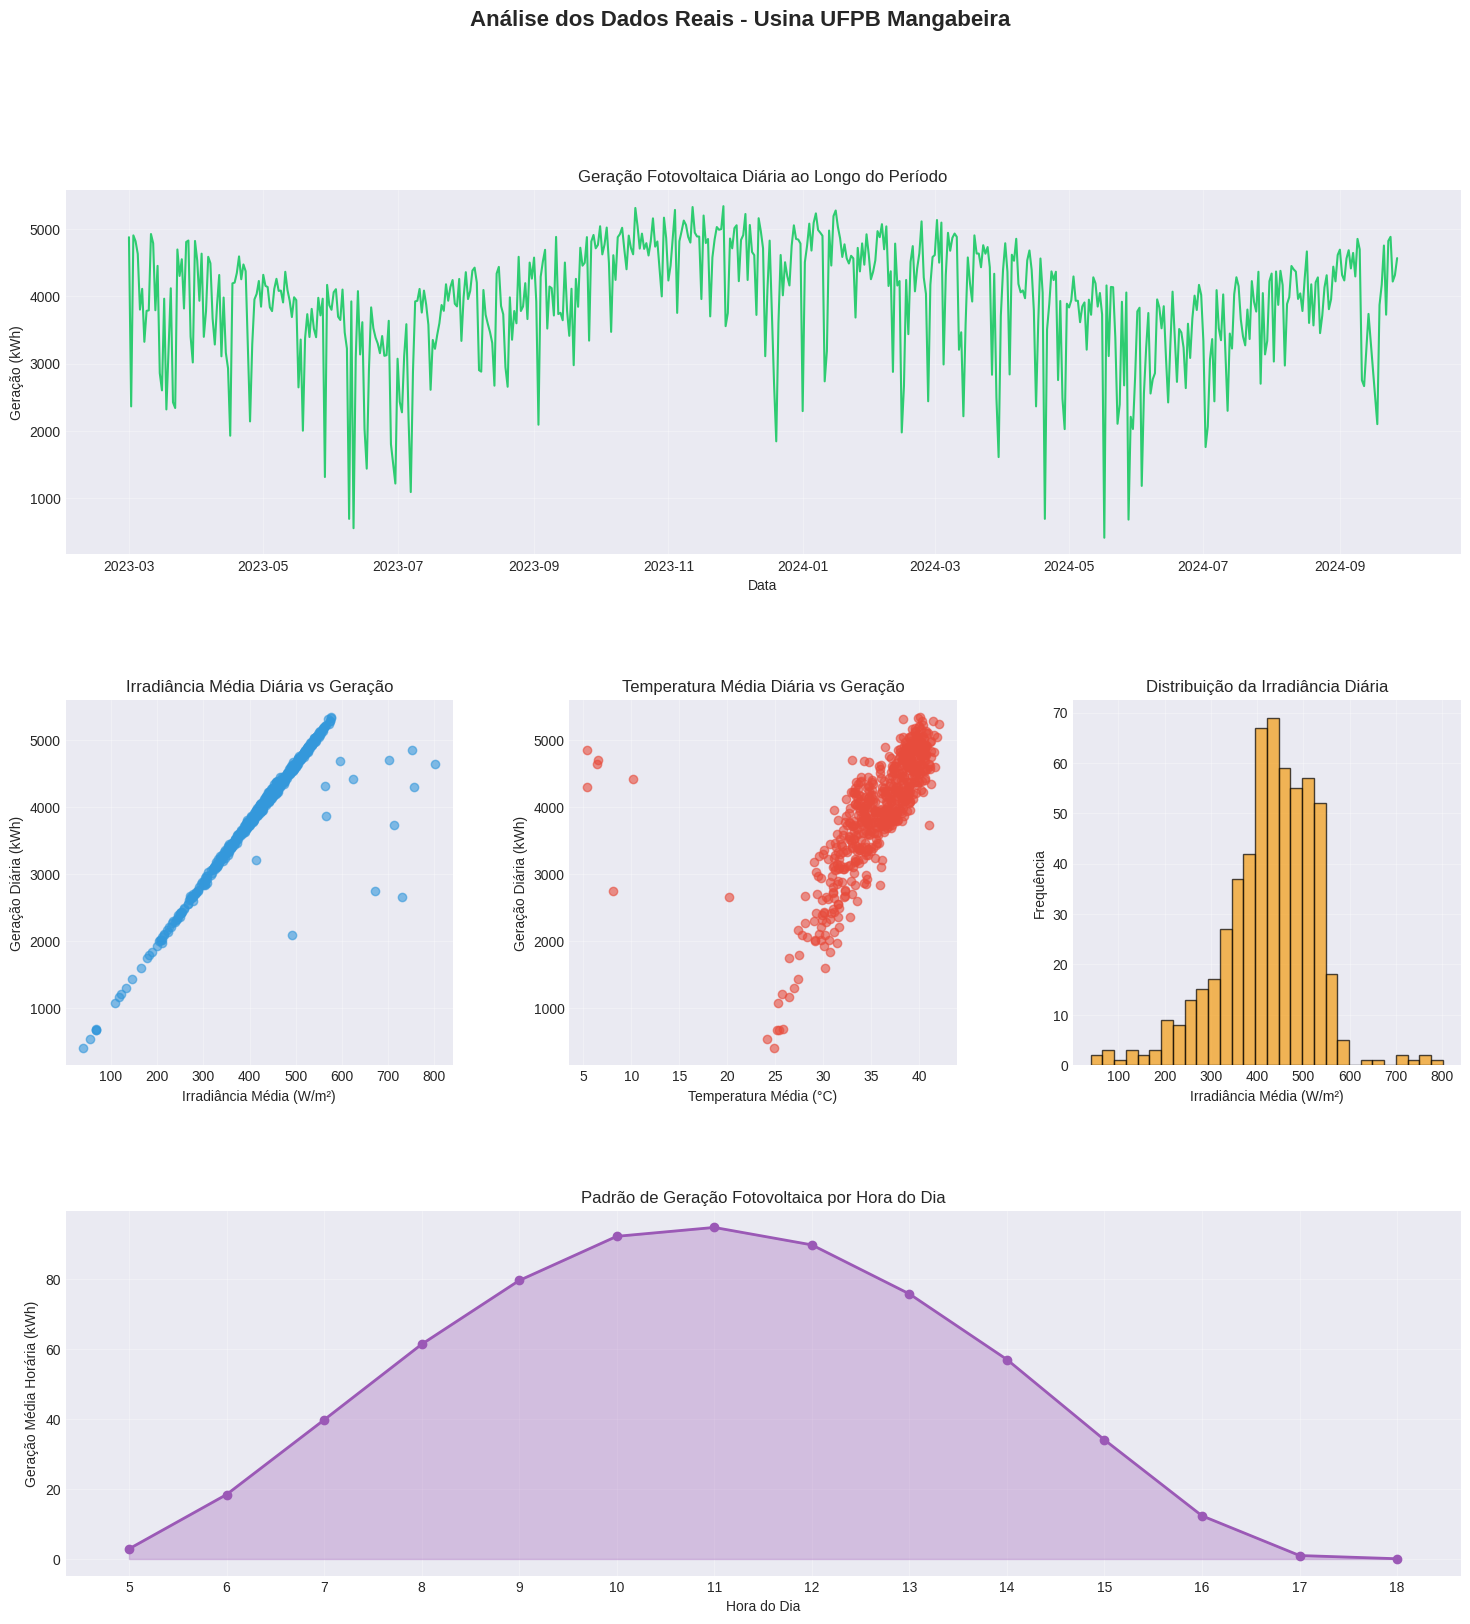

✓ analise_dados_reais.png

🌲 Treinando Random Forest...

MÉTRICAS DE DESEMPENHO - Random Forest
MSE:   57872.2082
RMSE:  240.5664
MAE:   60.3896
MAPE:  2.93%
R²:    0.9175


🚀 Treinando Gradient Boosting...

MÉTRICAS DE DESEMPENHO - Gradient Boosting
MSE:   67310.8811
RMSE:  259.4434
MAE:   54.7556
MAPE:  2.27%
R²:    0.9040


🎯 Treinando SVM...

MÉTRICAS DE DESEMPENHO - Support Vector Machine
MSE:   109715.3866
RMSE:  331.2331
MAE:   98.3698
MAPE:  9.27%
R²:    0.8435


🧠 Treinando Rede Neural Artificial...

MÉTRICAS DE DESEMPENHO - Rede Neural Artificial (MLP)
MSE:   94464.7297
RMSE:  307.3512
MAE:   199.2210
MAPE:  8.40%
R²:    0.8653



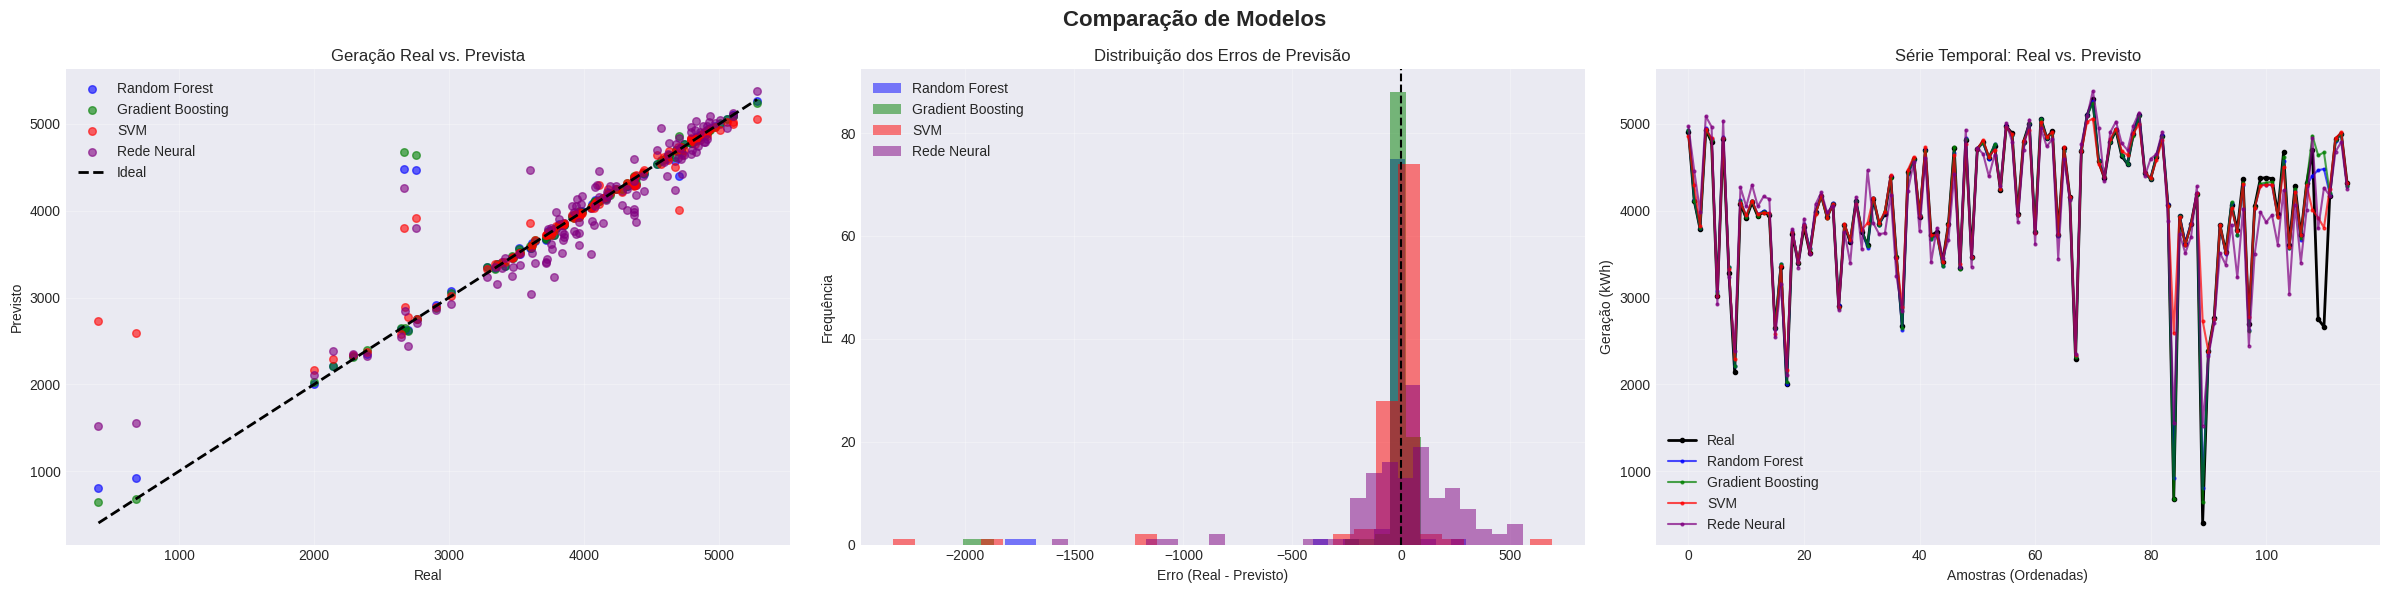

✓ comparacao_modelos_reais.png

 RESUMO FINAL

                            MSE      RMSE       MAE    MAPE      R2
Random Forest       57872.2082  240.5664   60.3896  2.9272  0.9175
Gradient Boosting   67310.8811  259.4434   54.7556  2.2710  0.9040
SVM                109715.3866  331.2331   98.3698  9.2655  0.8435
Rede Neural         94464.7297  307.3512  199.2210  8.4048  0.8653

🏆 MELHOR MODELO: Random Forest
   • RMSE: 240.5664 kWh
   • MAE:  60.3896 kWh
   • R²:   0.9175
   • MAPE: 2.93%

📁 Arquivos salvos em: /content/output_plots
   • resultados_modelos.csv
   • dados_processados.csv
   • analise_dados_reais.png
   • comparacao_modelos.png

 ✅ SIMULAÇÃO CONCLUÍDA!



In [ ]:
# 1. Carregar Dados
df_diario, df_diurno = carregar_e_preparar_dados()

# Definir diretório de saída para os gráficos
DIR_SAIDA = 'output_plots'
os.makedirs(DIR_SAIDA, exist_ok=True)

# 2. Plotar Análise Exploratória
plotar_dados_reais(df_diario, df_diurno)

# 3. Preparar Dados para ML (com Scaling)
X_train, X_test, y_train, y_test, scaler, idx_test = preparar_dados_ml(df_diario)

# 4. Treinar Modelos
rf_model, rf_pred, rf_metrics = treinar_random_forest(X_train, y_train, X_test, y_test)
gb_model, gb_pred, gb_metrics = treinar_gradient_boosting(X_train, y_train, X_test, y_test)
svm_model, svm_pred, svm_metrics = treinar_svm(X_train, y_train, X_test, y_test)
rna_model, rna_pred, rna_metrics = treinar_rede_neural(X_train, y_train, X_test, y_test)

# 5. Comparar Modelos Graficamente
predicoes = {
    'Random Forest': rf_pred,
    'Gradient Boosting': gb_pred,
    'SVM': svm_pred,
    'Rede Neural': rna_pred
}
plotar_comparacao_modelos(y_test, predicoes, idx_test)

print("\n" + "="*70)
print(" RESUMO FINAL")
print("="*70)

resultados = pd.DataFrame({
    'Random Forest': rf_metrics,
    'Gradient Boosting': gb_metrics,
    'SVM': svm_metrics,
    'Rede Neural': rna_metrics
}).T

print("\n", resultados.round(4).to_string())

melhor = resultados['RMSE'].idxmin()
print(f"\n{'='*70}")
print(f"🏆 MELHOR MODELO: {melhor}")
print(f"   • RMSE: {resultados.loc[melhor, 'RMSE']:.4f} kWh")
print(f"   • MAE:  {resultados.loc[melhor, 'MAE']:.4f} kWh")
print(f"   • R²:   {resultados.loc[melhor, 'R2']:.4f}")
print(f"   • MAPE: {resultados.loc[melhor, 'MAPE']:.2f}%")
print(f"{'='*70}")

resultados.to_csv(os.path.join(DIR_SAIDA, 'resultados_modelos.csv'))
df_diario.to_csv(os.path.join(DIR_SAIDA, 'dados_processados.csv'), index=False)

print(f"\n📁 Arquivos salvos em: {os.path.abspath(DIR_SAIDA)}")
print("   • resultados_modelos.csv")
print("   • dados_processados.csv")
print("   • analise_dados_reais.png")
print("   • comparacao_modelos.png")

print("\n" + "="*70)
print(" ✅ SIMULAÇÃO CONCLUÍDA!")
print("="*70 + "\n")